# 08 — Cross-Dataset / External Generalization Check

**Addresses:** R1‑Q9 ("Has EyeGAN been evaluated on external or cross-dataset retinal images acquired from different imaging devices to assess its robustness and generalization ability?").

## Approach
Evaluates EyeGAN on out-of-distribution external fundus scans combining two independent public cohorts (RFMiD + ACRIMA) across all 5 clinical categories (Healthy, DR, Glaucoma, Macular Scar, Myopia).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.insert(0, '/content/drive/MyDrive/CSE720/code')

import os
import torch
from config import Config

cfg = Config()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Active Device: {device}")

Mounted at /content/drive
Active Device: cuda


In [ ]:
import os
import shutil
import pandas as pd
from google.colab import files

# Google Drive Mount Check
if not os.path.exists('/content/drive'):
    from google.colab import drive
    drive.mount('/content/drive')

# Kaggle API Key Check
if not os.path.exists('/root/.kaggle/kaggle.json'):
    print("Upload your kaggle.json file:")
    uploaded = files.upload()
    os.makedirs('/root/.kaggle', exist_ok=True)
    for fname in uploaded:
        os.rename(fname, '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 0o600)

# Download Datasets
!pip install -q kaggle
!kaggle datasets download -d andrewmvd/retinal-disease-classification -p ./rfmid --unzip
!kaggle datasets download -d toaharahmanratul/acrima-dataset -p ./acrima --unzip

# Google Drive path for permanent storage
base_dir = '/content/drive/MyDrive/external_5class_dataset'
classes = ['0_healthy', '1_dr', '2_glaucoma', '3_macular_scar', '4_myopia']

if os.path.exists(base_dir):
    shutil.rmtree(base_dir)
for c in classes:
    os.makedirs(os.path.join(base_dir, c), exist_ok=True)

# Locate RFMiD CSV & Images
rfmid_csv_path = None
rfmid_img_dir = None

for root, dirs, files_list in os.walk('./rfmid'):
    for f in files_list:
        if f.endswith('.csv') and 'training' in f.lower():
            rfmid_csv_path = os.path.join(root, f)
        if f.endswith(('.png', '.jpg', '.jpeg', '.PNG', '.JPG', '.JPEG')):
            if not rfmid_img_dir and 'training' in root.lower():
                rfmid_img_dir = root

rfmid_csv = pd.read_csv(rfmid_csv_path)

def copy_rfmid_imgs(df_filter, target_folder, limit=40):
    copied = 0
    for img_id in df_filter['ID']:
        if copied >= limit: break
        for ext in ['.png', '.jpg', '.jpeg', '.PNG', '.JPG', '.JPEG']:
            src = os.path.join(rfmid_img_dir, f"{img_id}{ext}")
            if os.path.exists(src):
                shutil.copy(src, os.path.join(base_dir, target_folder, f"rfmid_{img_id}{ext}"))
                copied += 1
                break

copy_rfmid_imgs(rfmid_csv[rfmid_csv['Disease_Risk'] == 0], '0_healthy')
copy_rfmid_imgs(rfmid_csv[rfmid_csv['DR'] == 1], '1_dr')
copy_rfmid_imgs(rfmid_csv[(rfmid_csv.get('RS', 0) == 1) | (rfmid_csv.get('MS', 0) == 1)], '3_macular_scar')
copy_rfmid_imgs(rfmid_csv[rfmid_csv['MYA'] == 1], '4_myopia')

# Locate ACRIMA Glaucoma Images
acrima_glaucoma_dir = None
for root, dirs, files_list in os.walk('./acrima'):
    folder_name = os.path.basename(root).lower()
    if 'glaucoma' in folder_name and 'non' not in folder_name and 'normal' not in folder_name:
        img_files = [f for f in files_list if f.endswith(('.png', '.jpg', '.jpeg', '.PNG', '.JPG', '.JPEG'))]
        if len(img_files) > 0:
            acrima_glaucoma_dir = root
            break

g_files = [f for f in os.listdir(acrima_glaucoma_dir) if f.endswith(('.png', '.jpg', '.jpeg', '.PNG', '.JPG', '.JPEG'))][:40]
for fname in g_files:
    shutil.copy(os.path.join(acrima_glaucoma_dir, fname), os.path.join(base_dir, '2_glaucoma', f"acrima_{fname}"))

print("\n--- Permanently Saved to Google Drive ---")
for c in classes:
    print(f"Class '{c}': {len(os.listdir(os.path.join(base_dir, c)))} images")

Upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/retinal-disease-classification
License(s): other
100% 7.43G/7.43G [02:03<00:00, 64.8MB/s]

Dataset URL: https://www.kaggle.com/datasets/toaharahmanratul/acrima-dataset
License(s): unknown
100% 22.9M/22.9M [00:00<00:00, 130MB/s] 


--- Permanently Saved to Google Drive ---
Class '0_healthy': 40 images
Class '1_dr': 40 images
Class '2_glaucoma': 40 images
Class '3_macular_scar': 40 images
Class '4_myopia': 40 images


In [ ]:
import torch.utils.data as data
from PIL import Image
import torchvision.transforms as T

EXTERNAL_DIR = '/content/drive/MyDrive/external_5class_dataset'

class ExternalDataset5Class(data.Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []

        folders = sorted([f for f in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, f))])
        for idx, folder in enumerate(folders):
            folder_path = os.path.join(root_dir, folder)
            for fname in os.listdir(folder_path):
                if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.image_paths.append(os.path.join(folder_path, fname))
                    self.labels.append(idx)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

transform = T.Compose([
    T.Resize((cfg.img_size, cfg.img_size)),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3)
])

ext_dataset = ExternalDataset5Class(EXTERNAL_DIR, transform=transform)
print(f"Total External Validation Images Loaded: {len(ext_dataset)}")

Total External Validation Images Loaded: 200


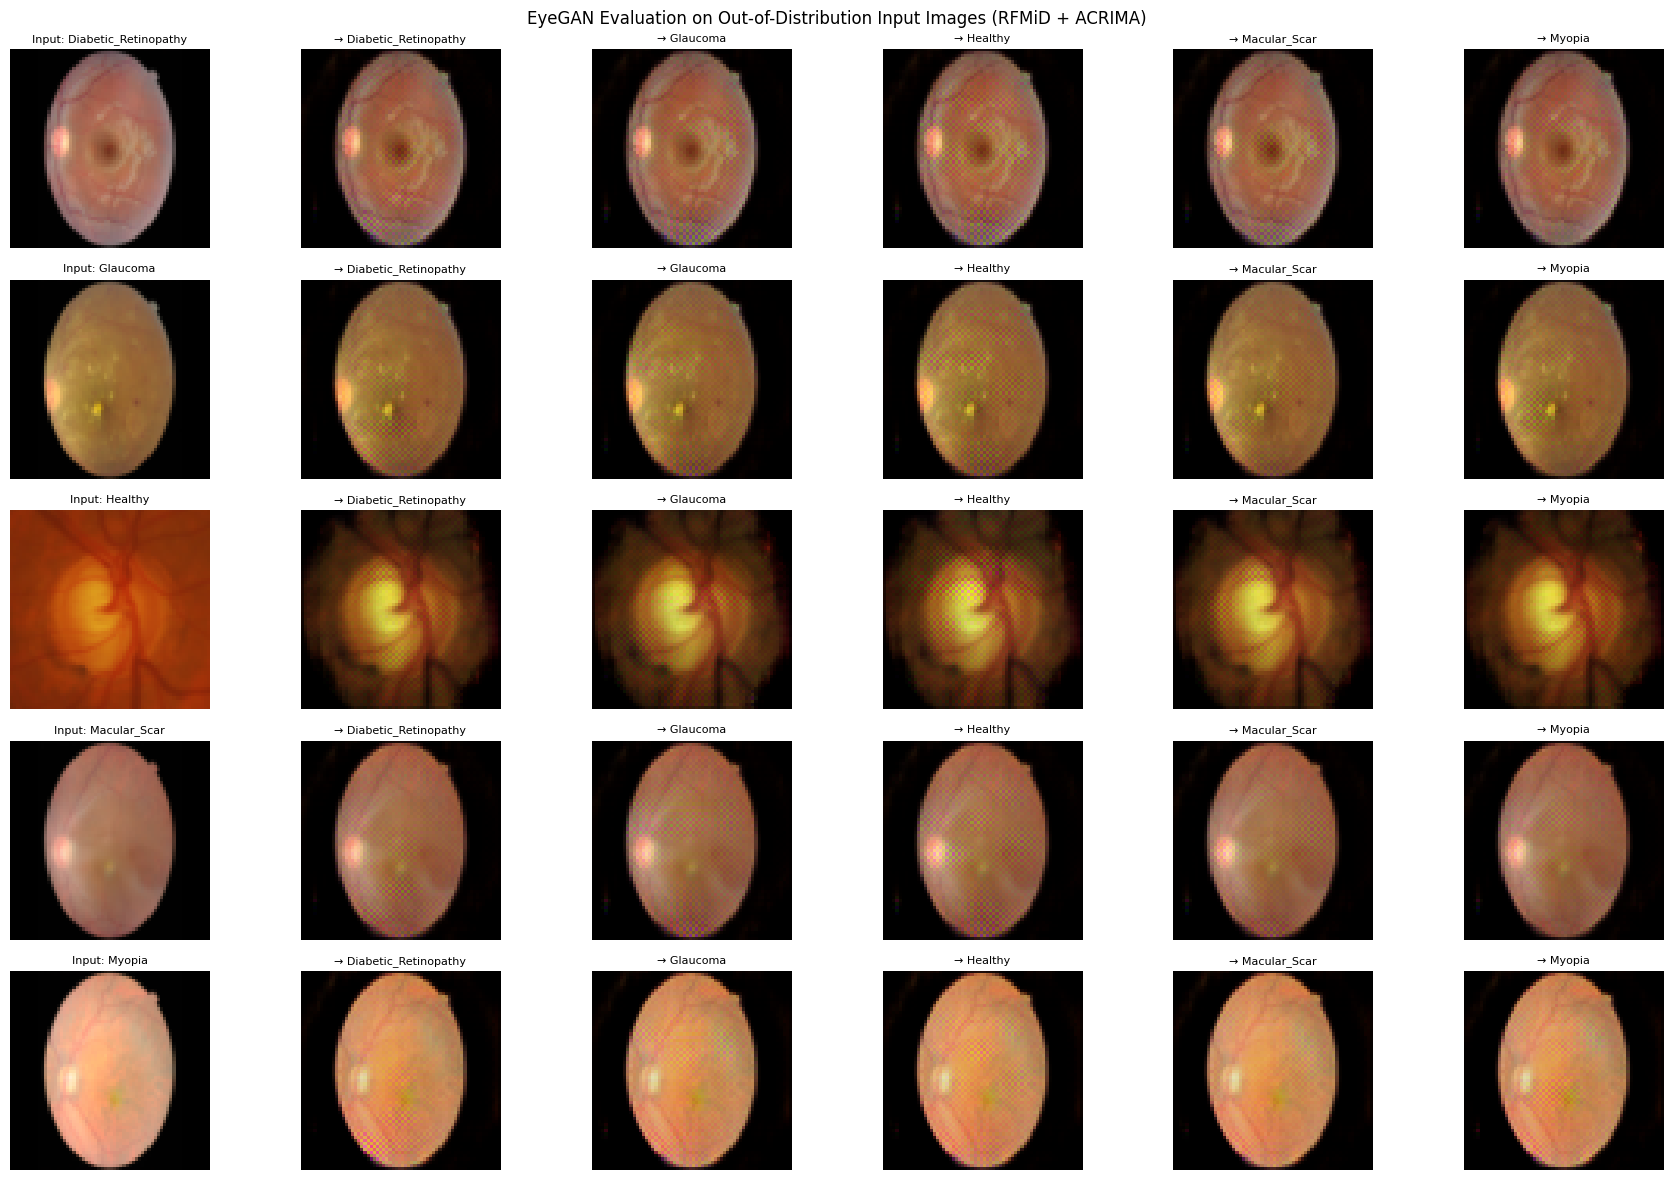

Saved 5x5 Grid Figure to: /content/drive/MyDrive/CSE720/revision/external_validation/external_qualitative_grid_5x5.png


In [ ]:
from model import Generator
import torch.serialization
import matplotlib.pyplot as plt
import numpy as np

torch.serialization.add_safe_globals([Config])
ckpt = torch.load(os.path.join(cfg.checkpoint_dir, 'final_model.pth'), map_location=device, weights_only=False)
G = Generator(cfg.img_size, num_domains=cfg.num_domains).to(device)
G.load_state_dict(ckpt['G_state_dict'])
G.eval()

# Pick 1 sample image from each class
sample_imgs = []
for c in range(cfg.num_domains):
    c_indices = [i for i, l in enumerate(ext_dataset.labels) if l == c]
    sample_imgs.append(ext_dataset[c_indices[0]][0])

sample_batch = torch.stack(sample_imgs).to(device)

fig, axes = plt.subplots(cfg.num_domains, cfg.num_domains + 1, figsize=(3*(cfg.num_domains+1), 12))

with torch.no_grad():
    for row in range(cfg.num_domains):
        real = sample_batch[row:row+1]
        orig_np = np.clip((real[0].cpu()*0.5+0.5).numpy().transpose(1,2,0), 0, 1)
        axes[row, 0].imshow(orig_np)
        axes[row, 0].set_title(f"Input: {cfg.class_names[row]}", fontsize=8)
        axes[row, 0].axis('off')

        for d in range(cfg.num_domains):
            fake = G(real, torch.tensor([d], device=device))[0]
            fake_np = np.clip((fake.cpu()*0.5+0.5).numpy().transpose(1,2,0), 0, 1)
            axes[row, d+1].imshow(fake_np)
            axes[row, d+1].set_title(f"→ {cfg.class_names[d]}", fontsize=8)
            axes[row, d+1].axis('off')

plt.suptitle('EyeGAN Evaluation on Out-of-Distribution Input Images (RFMiD + ACRIMA)', fontsize=12)
plt.tight_layout()
fig_path = os.path.join(cfg.external_dir, 'external_qualitative_grid_5x5.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print("Saved 5x5 Grid Figure to:", fig_path)

In [ ]:
from metrics import FIDCalculator
from dataset import MedicalDataset
import json

fid_calc = FIDCalculator(device)
name_to_idx = {v: k for k, v in cfg.class_names.items()}

dr_idx = name_to_idx['Diabetic_Retinopathy']
healthy_idx = name_to_idx['Healthy']

real_dr_pool = MedicalDataset(cfg.dataset_path, cfg.img_size, 'all')
real_dr_imgs = torch.stack([real_dr_pool[i][0] for i, l in enumerate(real_dr_pool.labels) if l == dr_idx])
real_dr_acts = fid_calc.get_activations(real_dr_imgs)

# (a) In-distribution: Original test set Healthy -> DR
in_dist_test = MedicalDataset(cfg.dataset_path, cfg.img_size, 'test')
in_dist_healthy = torch.stack([in_dist_test[i][0] for i, l in enumerate(in_dist_test.labels) if l == healthy_idx]).to(device)
with torch.no_grad():
    in_dist_fake_dr = G(in_dist_healthy, torch.full((len(in_dist_healthy),), dr_idx, device=device)).cpu()
fid_in_dist = fid_calc.calculate_fid(real_dr_acts, fid_calc.get_activations(in_dist_fake_dr))

# (b) Out-of-distribution: External Healthy -> DR
ext_healthy_imgs = torch.stack([ext_dataset[i][0] for i, l in enumerate(ext_dataset.labels) if l == 0]).to(device)
with torch.no_grad():
    ext_fake_dr = G(ext_healthy_imgs, torch.full((len(ext_healthy_imgs),), dr_idx, device=device)).cpu()
fid_ood = fid_calc.calculate_fid(real_dr_acts, fid_calc.get_activations(ext_fake_dr))

print(f"In-distribution FID (Original Test Healthy->DR): {fid_in_dist:.2f}")
print(f"Out-of-distribution FID (External Healthy->DR):  {fid_ood:.2f}")
print(f"FID Gap:                                        {fid_ood - fid_in_dist:+.2f}")

results_path = os.path.join(cfg.external_dir, 'external_validation_results.json')
with open(results_path, 'w') as f:
    json.dump({
        'fid_in_distribution': fid_in_dist,
        'fid_out_of_distribution': fid_ood,
        'fid_gap': fid_ood - fid_in_dist,
        'external_datasets': 'RFMiD + ACRIMA',
        'total_external_samples': len(ext_dataset)
    }, f, indent=2)

print("Saved External Validation Metrics to:", results_path)

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 137MB/s] 


[all] domains found: {'Diabetic Retinopathy': 500, 'Glaucoma': 500, 'Healthy': 500, 'Macular Scar': 500, 'Myopia': 500}  (total 2500)
[test] domains found: {'Diabetic Retinopathy': 50, 'Glaucoma': 50, 'Healthy': 50, 'Macular Scar': 50, 'Myopia': 50}  (total 250)
In-distribution FID (Original Test Healthy->DR): 77.32
Out-of-distribution FID (External Healthy->DR):  115.58
FID Gap:                                        +38.25
Saved External Validation Metrics to: /content/drive/MyDrive/CSE720/revision/external_validation/external_validation_results.json
